In [2]:
# import block
import requests
import json
import pandas as pd
import pprint
import xml.etree.ElementTree as ET
import time
import xmltodict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import fuzz, process
import re 

**API query**

Last run date: 10.04.2026

In [ ]:
# define credentials
fs_username = "DEFINE USERNAME HERE"
fs_password = "PASTE PASSWORD HERE"

# login
login_url = "https://api.fairsharing.org/users/sign_in"
headers = {
    'Accept': 'application/json',
    'Content-Type': 'application/json'
}
payload = {
    "user": {
        "login": fs_username,
        "password": fs_password
    }
}

# send POST request
response = requests.post(login_url, headers=headers, data=json.dumps(payload))
response.raise_for_status()  # raise error if login fails

# get jwt and sacve
data = response.json()
jwt = data['jwt']
print("Login successful! JWT token received.")
print("JWT preview (first 50 chars):", jwt[:50])


records_all = []

base_url = "https://api.fairsharing.org/fairsharing_records/"

headers = {
    "Accept": "application/json",
    "Authorization": f"Bearer {jwt}"
}

page_number = 1
page_size = 100

while True:
    params = {
        "page[number]": page_number,
        "page[size]": page_size
    }

    response = requests.get(
        base_url,
        headers=headers,
        params=params
    )
    response.raise_for_status()

    data = response.json()

    records = data.get("data", [])

    if not records:
        print("No more records found.")
        break

    records_all.extend(records)

    print(f"Retrieved page {page_number}, total records so far: {len(records_all)}")

    page_number += 1

print(f"\nFinished! Total FAIRsharing records retrieved: {len(records_all)}")

print(records_all[0].keys())
pprint.pprint(records_all[0])

# save
with open("data/records_all.json", "w") as f:
    json.dump(records_all, f, indent=2)


**1. Filtering for databases**

In [56]:
with open("data/records_all.json", "r") as f:
    records_all = json.load(f)

In [57]:
databases_all = []

for rec in records_all:
        attrs = rec.get("attributes", {})

        if(attrs.get("fairsharing_registry") == "Database"):
                databases_all.append(rec)

print(F"Databases found: {len(databases_all)}")

Databases found: 3072


**2. Filtering for COVID databases with keyword search**

First, we search for the root term "cov" and the word "corona" within the metadata to capture various ways COVID-19 might be referenced. The search covers four metadata fields: domains, tags, taxonomies, and descriptions. The results are displayed below.

In [58]:
# keywords to search for
search_terms = ["cov", "corona"]

# dictionary for all unique matches
potential_filters = {
    "domains": set(),
    "user_defined_tags": set(),
    "taxonomies": set()
}

for rec in databases_all:
    attrs = rec.get("attributes", {})
    
    for field in potential_filters.keys():
        tags = attrs.get(field, [])
        if isinstance(tags, list):
            for tag in tags:
                if any(term in tag.lower() for term in search_terms):
                    potential_filters[field].add(tag)

# print results
for field, matches in potential_filters.items():
    print(f"\n--- Found in {field.upper()} ---")
    if not matches:
        print("None")
    for match in sorted(matches):
        print(match)


# check descriptions for matches
description_matches = set()

for rec in databases_all:
    desc = rec.get("attributes", {}).get("description", "")
    
    if desc:
        # split the description into individual words to find the specific match
        words = desc.lower().split()
        for word in words:
            # clean punctuation from the word 
            clean_word = "".join(char for char in word if char.isalnum() or char == '-')
            if any(term in clean_word for term in search_terms):
                description_matches.add(clean_word)

print("\n--- Found in DESCRIPTIONS ---")
if not description_matches:
    print("None")
else:
    for match in sorted(description_matches):
        print(match)


--- Found in DOMAINS ---
None

--- Found in USER_DEFINED_TAGS ---
COVID-19
Resource Discovery
acceptance of covid-19 vaccine

--- Found in TAXONOMIES ---
Circoviridae
Coronaviridae
Corticoviridae
HCoV-SARS
MERS-CoV
SARS-CoV-2
Secoviridae

--- Found in DESCRIPTIONS ---
anti-coronavirus
capacity-covid
coronal
coronavirus
coronaviruses
covalent
covariance
covdb
cover
coverage
coverages
covered
covering
covers
covid
covid-19
covid-19-related
covid-hep
covims
discover
discoverability
discoverable
discovered
discoverer
discoveries
discovering
discovery
discoverycharacterization
disscover
epicov
hcov-19
httpdiscoveryinformaticsuabedubeere
httpsenc-supportnudata-aanvraag-meerjarig-long-covid-onderzoek
land-cover
litcovid
low-coverage
mers-cov
neurodiscovery
plantscoverage
post-covid-19
recover
recoverable
recovered
sars-cov
sars-cov-2
uncover


After manually inspecting the results above, I selected only the terms actually related to COVID-19. Note that:

- the domains field returned no matches;

- the descriptions field included irrelevant hits (e.g., "discover" contains "cov" but is unrelated).

We initially search for the root "cov" as an exploratory step to capture all possible COVID-19 variations (e.g., SARS-CoV-2, MERS-CoV) without missing anything. From the results, I manually curate a final keyword list that:

- avoids false positives from unrelated "cov" matches &

- captures relevant COVID-19 word variations.

This keyword list is used for filtering in the next step.

In [59]:
covid_search_terms = {"covid", "coronavirus", "coronaviridae", "sars-cov-2", "mers-cov", "hcov-sars", "hcov-19", "2019-ncov"}

covid_databases = []

for rec in databases_all:
    attrs = rec.get("attributes", {})
    
    # collect all terms and lowercase
    tags = [t.lower() for t in (attrs.get("user_defined_tags", []) or [])]
    taxa = [t.lower() for t in (attrs.get("taxonomies", []) or [])]
    desc = (attrs.get("description", "") or "").lower()

    # is any keyword a substring of any item in this list?
    found_in_tags = any(term in tag for tag in tags for term in covid_search_terms)
    found_in_taxa = any(term in taxon for taxon in taxa for term in covid_search_terms)
    found_in_desc = any(term in desc for term in covid_search_terms)

    if found_in_tags or found_in_taxa or found_in_desc:
        covid_databases.append(rec)

print(f"Total COVID-19 repositories identified: {len(covid_databases)}")

Total COVID-19 repositories identified: 134


In [60]:
counts = {}

for rec in covid_databases:
    # Get the string value, default to 'Unknown' if missing
    rtype = rec.get("attributes", {}).get("record_type", "Unknown")
    
    # Standard dictionary counter logic
    counts[rtype] = counts.get(rtype, 0) + 1


print("Filtering with keyword search returned this many records:")
for rtype, count in sorted(counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{rtype}: {count}")

Filtering with keyword search returned this many records:
repository: 84
knowledgebase: 37
knowledgebase_and_repository: 13


**Inspecting a single record to decide what metadata to extract**

In [17]:
pprint.pprint(covid_databases[2])

{'attributes': {'abbreviation': None,
                'countries': ['United States'],
                'created_at': '2014-11-04T15:23:40.000Z',
                'description': 'This FAIRsharing record describes: The '
                               'Antibody Registry exists to give researchers a '
                               'way to universally identify antibodies used in '
                               'publications. The registry lists many '
                               'commercial antibodies from about 200 vendors '
                               'which have each been assigned a unique '
                               'identifier. If the antibody that you are using '
                               'does not appear in the list, an entry can be '
                               'made by filling in as little as 2 pieces of '
                               'information: the catalog number and the url of '
                               'the vendor where our curators can find '
     

**Extracting metadata and creating a dataframe of identified COVID-related databases**

In [65]:
def extract_fairsharing_records(items, add_similarity=False):
    rows = []

    for item in items:
        rec = item['repo'] if isinstance(item, dict) and 'repo' in item else item
        score = item.get('similarity_score') if add_similarity and isinstance(item, dict) else None

        attrs = rec.get("attributes", {})
        meta = attrs.get("metadata", {})
        
        # funders
        grants_list = attrs.get("grants", [])
        funder_names, funder_types = [], []
        for g in grants_list:
            state = g.get("saved_state", {})
            if state.get("relation") == "funds":
                funder_names.append(state.get("name", "N/A"))
                funder_types.append(", ".join(state.get("types", [])))

        # maintainers
        maintaining_names, maintaining_types = [], []
        for g in grants_list:
            state = g.get("saved_state", {})
            if state.get("relation") == "maintains":
                maintaining_names.append(state.get("name", "N/A"))
                maintaining_types.append(", ".join(state.get("types", [])))
                
        # publications DOIs
        dois = [p.get("doi") for p in attrs.get("publications", []) if p.get("doi")]

        # contacts
        contacts_list = meta.get("contacts", [])
        c_names = [c.get('contact_name') for c in contacts_list if c.get('contact_name')]
        c_emails = [c.get('contact_email') for c in contacts_list if c.get('contact_email')]

        # licence links
        licence_list = attrs.get("licence_links", [])
        licences = [l.get('licence_name') for l in licence_list if l.get('licence_name')]
        licence_urls = [l.get('licence_url') for l in licence_list if l.get('licence_url')]

        # linking records
        linking_list = attrs.get("linking_records", [])
        related_standard_names, standard_relations = [], []
        for lr in linking_list:
            if lr.get("relation") in {"implements", "accepts", "outputs"}:
                related_standard_names.append(lr.get("linking_record_name"))
                standard_relations.append(lr.get("relation"))

        # cross references
        cross_references = [cr.get("url") for cr in meta.get("cross_references", []) if cr.get("url")]

        # data preservation policy
        dp_policy = meta.get("data_preservation_policy")
        data_preservation_policy = dp_policy.get("name") if isinstance(dp_policy, dict) and dp_policy else None

        row = {
            "name": meta.get("name"),
            "abbreviation": attrs.get("abbreviation"),
            "url": meta.get("homepage"),
            "fs_id": rec.get("id"),
            "fs_doi": attrs.get("doi"),
            "description": meta.get("description"),
            "status": meta.get("status"),
            "record_type": attrs.get("record_type"),
            "countries": "; ".join(attrs.get("countries")) if attrs.get("countries") else None,
            "year_created": meta.get("year_creation"),
            "funder": "; ".join(funder_names) if funder_names else None,
            "funder_type": "; ".join(set(funder_types)) if funder_types else None,
            "maintaining_institution": "; ".join(maintaining_names) if maintaining_names else None,
            "maintaining_type": "; ".join(set(maintaining_types)) if maintaining_types else None,
            "contact_name": "; ".join(c_names) if c_names else None,
            "contact_email": "; ".join(c_emails) if c_emails else None,
            "data_access_condition": (meta.get("data_access_condition") or {}).get("type"),
            "data_deposition_condition": (meta.get("data_deposition_condition") or {}).get("type"),
            "data_preservation_policy": data_preservation_policy,
            "linked_licence_name": "; ".join(licences) if licences else None,
            "linked_licence_url": "; ".join(licence_urls) if licence_urls else None,
            "related_standard_name": "; ".join(related_standard_names) if related_standard_names else None,
            "standard_relation": "; ".join(standard_relations) if standard_relations else None,
            "cross_references": "; ".join(cross_references) if cross_references else None,
            "object_types": "; ".join(attrs.get("object_types")) if attrs.get("object_types") else None,
            "subjects": "; ".join(attrs.get("subjects")) if attrs.get("subjects") else None,
            "tags": "; ".join(attrs.get("user_defined_tags")) if attrs.get("user_defined_tags") else None,
            "publications": "; ".join(dois) if dois else None,
            "similarity_score": score if add_similarity else None
        }

        rows.append(row)

    df = pd.DataFrame(rows)

    if 'year_created' in df.columns:
        df['year_created'] = (
            pd.to_numeric(df['year_created'], errors='coerce')
            .fillna(0)
            .astype(int)
            .replace(0, "")
        )

    if add_similarity and df['similarity_score'].notna().any():
        df = df.sort_values(by="similarity_score", ascending=False, ignore_index=True)
    else:
        df = df.sort_values(by='name', ignore_index=True)

    return df

In [66]:
df_covid = extract_fairsharing_records(covid_databases)

In [67]:
df_covid['year_created']

0      2022
1          
2      2004
3      2017
4      2020
       ... 
129    2011
130    2020
131    2015
132    2012
133    2014
Name: year_created, Length: 134, dtype: object

In [68]:
display(df_covid.head(10))
df_covid.info()

,name,abbreviation,url,fs_id,fs_doi,description,status,record_type,countries,year_created,...,linked_licence_name,linked_licence_url,related_standard_name,standard_relation,cross_references,object_types,subjects,tags,publications,similarity_score
0,COVID-19 Data Repository,None,https://www.openicpsr.org/openicpsr/covid19,4074,10.25504/FAIRsharing.eda566,The COVID-19 Data Repository is a repository f...,ready,repository,United States,2022,...,openICPSR Privacy Policy,https://www.openicpsr.org/openicpsr/privacy,None,None,None,dataset,Economics; Public Health; Social Science,COVID-19,None,None
1,AccessClinicalData@NIAID,None,https://accessclinicaldata.niaid.nih.gov/,5584,10.25504/FAIRsharing.40d9e9,AccessClinicalData@NIAID is a NIAID cloud-base...,ready,repository,United States,,...,None,None,None,None,None,document; dataset,Clinical Studies,COVID-19,None,None
2,Addgene,Addgene,https://www.addgene.org/,1738,10.25504/FAIRsharing.8hcczk,Addgene is a non-profit plasmid repository ded...,ready,repository,United Kingdom; United States,2004,...,Addgene Technology Transfer agreement; Addgene...,http://www.addgene.org/techtransfer/; https://...,None,None,https://www.re3data.org/repository/r3d10001074...,dataset; image,Life Science,COVID-19,10.1038/nbt.2177; 10.1038/505272a; 10.1093/nar...,None
3,Alliance of Genome Resources,None,https://www.alliancegenome.org,2530,10.25504/FAIRsharing.6ba5fw,The primary mission of the Alliance of Genome ...,ready,knowledgebase,United Kingdom; United States,2017,...,"Alliance of Genome Resources Privacy, Warranty...",https://www.alliancegenome.org/privacy-warrant...,None,None,None,dataset,Genomics,COVID-19,10.1093/nar/gkz813; 10.1534/genetics.119.302523,None
4,American Society of Clinical Oncology (ASCO) S...,ASCO Registry,https://old-prod.asco.org/covid-resources/asco...,3223,10.25504/FAIRsharing.BIZ2Nt,The American Society of Clinical Oncology (ASC...,deprecated,repository,United States,2020,...,ASCO Terms of Use; Information Sharing Policy ...,https://www.asco.org/about-asco/legal/terms-us...,None,None,None,document; questionnaire/survey; dataset,Critical Care Medicine; Clinical Studies; Epid...,COVID-19; Dashboard; Observations,None,None
5,Antibody Registry,None,https://antibodyregistry.org/,1725,10.25504/FAIRsharing.3wdd17,The Antibody Registry exists to give researche...,ready,repository,United States,2009,...,Antibody Registry Terms of Use; Creative Commo...,https://antibodyregistry.org/terms-and-conditi...,None,None,https://www.re3data.org/repository/r3d10001040...,dataset,Biomedical Science,COVID-19,10.1038/nmeth.2570; 10.1093/nar/gkac927,None
6,Arca Dados,None,https://arcadados.fiocruz.br/,5829,10.25504/FAIRsharing.efc718,Arca Dados is Fiocruz's official research data...,ready,repository,Brazil,2019,...,Creative Commons Attribution-NonCommercial 4.0...,https://creativecommons.org/licenses/by-nc/4.0/,None,None,https://www.re3data.org/repository/r3d100013904,dataset; image,Tropical Medicine; Clinical Studies; Health Se...,COVID-19; tropical disease,None,None
7,BBMRI-ERIC Directory,None,https://directory.bbmri-eric.eu/,2857,10.25504/FAIRsharing.q9VUYM,The BBMRI-ERIC Directory is a tool to share ag...,ready,repository,Austria; Belgium; Bulgaria; Cyprus; Czech Repu...,2015,...,None,None,None,None,https://www.re3data.org/repository/r3d100013028,dataset; other object type; software source code,Life Science; Human Biology; Health Science,COVID-19,10.1089/bio.2016.0088,None
8,Better Outcomes Registry & Network,BORN Ontario,https://www.bornontario.ca/en/index.aspx,4061,10.25504/FAIRsharing.424cb8,"Funded by the Government of Ontario, the Bette...",ready,repository,Canada,2020,...,BORN Data Privacy and Security,https://www.bornontario.ca/en/data/data-privac...,None,None,https://www.re3data.org/repository/r3d100013917,document; publication; dataset,Epidemiology; Obstetrics; Health Science; Medi...,COVID-19; Dashboard; Observations; Pregnancy,None,None
9,BioData.pt Data Management Portal,DMPortal,https://dmp

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   name                       134 non-null    object
 1   abbreviation               83 non-null     object
 2   url                        134 non-null    object
 3   fs_id                      134 non-null    object
 4   fs_doi                     129 non-null    object
 5   description                134 non-null    object
 6   status                     134 non-null    object
 7   record_type                134 non-null    object
 8   countries                  132 non-null    object
 9   year_created               134 non-null    object
 10  funder                     70 non-null     object
 11  funder_type                70 non-null     object
 12  maintaining_institution    120 non-null    object
 13  maintaining_type           120 non-null    object
 14  contact_na

In [71]:
# rows where data_preservation_policy is not empty (not None, not NaN, not empty string)
df_preservation = df_covid[
    df_covid['data_preservation_policy'].notna()
    & (df_covid['data_preservation_policy'] != '')
]

cols_to_show = [
    'name',
    'abbreviation',
    'data_preservation_policy',
    'data_access_condition',
    'data_deposition_condition',
    'year_created'
]

df_preservation[cols_to_show]

,name,abbreviation,data_preservation_policy,data_access_condition,data_deposition_condition,year_created
5,Antibody Registry,None,"if all else fails, the data licensed at CC-0 w...",open,open,2009
74,Image Data Resource,IDR,Follows EMBL-EBI’s open data mission in the do...,open,open,2015
75,Immunology Database and Analysis Portal,ImmPort,"DAIT, NIAID, NIH Support Funding (duration up ...",partially open,controlled,2007
80,Johns Hopkins Coronavirus Resource,None,"March 10, 2023, the Johns Hopkins Coronavirus ...",partially open,not applicable,2020
84,LitCovid,LitCovid,not found,open,not applicable,2020
113,TARKI Data Archive,TARKI,not specified,controlled,controlled,1985
128,WorkflowHub,None,"Should WorkflowHub reach its end of service, i...",open,open,2020


In [70]:
# save df in output folder
df_covid.to_csv("data/covid_databases.csv", index=False)

In [ ]:
print("\n=== SUBJECTS STATS ===")
# Count how many registries have each subject
subjects_counts = {}
for row in df_covid['subjects']:
    if pd.notna(row) and row:
        if isinstance(row, str):
            subjects = [s.strip() for s in row.split(';')]
        else:
            subjects = row
        for s in subjects:
            subjects_counts[s] = subjects_counts.get(s, 0) + 1

print(f"Total unique subjects: {len(subjects_counts)}")
print("Top 10 most common subjects:")
top_subjects = sorted(subjects_counts.items(), key=lambda x: x[1], reverse=True)[:10]
for subj, count in top_subjects:
    print(f"  {subj}: {count}")

print("\n=== TAGS STATS ===")
# Count how many registries have each tag
tags_counts = {}
for row in df_covid['tags']:
    if pd.notna(row) and row:
        if isinstance(row, str):
            tags = [t.strip() for t in row.split(';')]
        else:
            tags = row
        for t in tags:
            tags_counts[t] = tags_counts.get(t, 0) + 1

print(f"Total unique tags: {len(tags_counts)}")
print("Top 10 most common tags:")
top_tags = sorted(tags_counts.items(), key=lambda x: x[1], reverse=True)[:10]
for tag, count in top_tags:
    print(f"  {tag}: {count}")

print("\n=== OBJECT TYPES STATS ===")
object_types_counts = {}
for row in df_covid['object_types']:
    if pd.notna(row) and row:
        if isinstance(row, str):
            obj_types = [o.strip() for o in row.split(';')]
        else:
            obj_types = row
        for o in obj_types:
            object_types_counts[o] = object_types_counts.get(o, 0) + 1

print(f"Total unique object types: {len(object_types_counts)}")
print("All object types:")
for obj_type, count in sorted(object_types_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {obj_type}: {count}")



=== SUBJECTS STATS ===
Total unique subjects: 98
Top 10 most common subjects:
  Epidemiology: 63
  Clinical Studies: 45
  Virology: 44
  Medical Virology: 39
  Health Science: 37
  Life Science: 32
  Infectious Disease Medicine: 29
  Medicine: 27
  Biomedical Science: 25
  Genomics: 20

=== TAGS STATS ===
Total unique tags: 43
Top 10 most common tags:
  COVID-19: 123
  Observations: 28
  Dashboard: 27
  Psoriasis: 3
  Pregnancy: 2
  Cirrhosis: 2
  hepatology: 2
  Multiple Sclerosis: 2
  tropical disease: 1
  liver transplantation: 1

=== OBJECT TYPES STATS ===
Total unique object types: 14
All object types:
  dataset: 112
  image: 38
  document: 20
  model: 20
  publication: 19
  questionnaire/survey: 17
  object type not found: 8
  other object type: 6
  software source code: 4
  software application: 3
  protocol or workflow: 3
  physical object/material: 2
  multimedia: 2
  terminology artifact: 1


In [51]:
# Filter for registries without 'dataset' in object_types
no_dataset = df_covid[
    df_covid['object_types'].str.lower().str.contains('dataset', na=False) == False
]

print(f"\nFound {len(no_dataset)} registries WITHOUT 'dataset' object type:")
no_dataset[['name', 'abbreviation', 'object_types']]


Found 22 registries WITHOUT 'dataset' object type:


,name,abbreviation,object_types
12,BioSamples,BioSD,physical object/material
15,BridgeDb,None,other object type
28,COVID-19 Research Collaborations,None,object type not found
30,COVID-HEP Registry,None,object type not found
33,Cardiac complicAtions in Patients With SARS Co...,CAPACITY-COVID,other object type
35,Chinese Clinical Trial Registry,ChiCTR,other object type
40,Coronavirus and Atopic Dermatitis (AD) / Alope...,SECURE-DERM,questionnaire/survey
41,Coronavirus and Celiac Disease Reporting Database,None,questionnaire/survey
42,Coronavirus and MS Reporting Database,None,questionnaire/survey
50,Disaster Lit,Disaster Lit,object type not found


**3. Look for more databases with similarity approach**

To capture COVID-19 databases that our keyword search might miss, we use a similarity-based approach. The idea is to find repositories that are semantically similar to the COVID-19 databases we already identified (via keywords). This comparison is done programmatically across multiple metadata fields.

The method works as follows:

**1. The metadata "soup":**

Instead of looking at subjects, tags, or domains separately, we combine all of the information for each repository into one block of text = like a soup.


**2. Identifying the "important" words:**

Not all words are equally useful or informative. For example, the subject "epidemiology" appears a lot but it's a very broad category and so it might not help distinguishing one repository from another. So we give the terms "weights" in a way that common words are downplayed and rare/ specific terms are highlighted. Specific method: TF-IDF.

**3. Building a "gold standard" COVID repository:**

We then look at the 84 COVID repositories that we already successfully identified and "take their average" to represent what a typical COVID repository would look like, thereby creating something like a mathematical gold standard.

**4. Similarity scoring**

Finally, we compare every repository in the database to the "gold standard" profile. This gives us similarity scores between 0 (nothing in common) and 1 (perfect match). Specific method: cosine similarity.

In [14]:
def create_soup(rec):
    attrs = rec.get("attributes", {})
    
    
    subjects = " ".join(attrs.get("subjects", []))
    tags = " ".join(attrs.get("user_defined_tags", []))
    domains = " ".join(attrs.get("domains", []))
    taxonomies = " ".join(attrs.get("taxonomies", []))
    
    # combine
    soup = f"{subjects} {tags} {domains} {taxonomies}"

    return " ".join(soup.lower().split())

# create a list of "soups" for ALL 3072 databases
all_soups = [create_soup(r) for r in databases_all]

In [15]:
# 1. turn repos into vectors (TF-IDF)
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(all_soups)

# 2. identify the indices of the 84 known COVID repos
covid_ids = [r['id'] for r in covid_databases] 
all_ids = [r['id'] for r in databases_all]
covid_indices = [all_ids.index(cid) for cid in covid_ids]

# 3. calculate 'centroid' (the average vector of COVID repos)
covid_vectors = tfidf_matrix[covid_indices]
centroid = np.asarray(covid_vectors.mean(axis=0))

# 4. calculate similarity of EVERY repo to that COVID centroid
similarities = cosine_similarity(tfidf_matrix, centroid).flatten()

# 5. attach the scores and filter out the ones we already know
cosine_results = []
for i, score in enumerate(similarities):
    if i not in covid_indices:
        cosine_results.append({
            'repo': databases_all[i],
            'similarity_score': score
        })

# sort by highest similarity
cosine_results = sorted(cosine_results, key=lambda x: x['similarity_score'], reverse=True)

In [73]:
with open("data/cosine_databases.json", "w") as f:
    json.dump(cosine_results, f, indent=2)

In [72]:
# convert to df for convenience
df_cosine_results = pd.DataFrame(cosine_results)
df_cosine_results.head()

,repo,similarity_score
0,"{'id': '7386', 'type': 'fairsharing_records', ...",0.410045
1,"{'id': '2719', 'type': 'fairsharing_records', ...",0.406009
2,"{'id': '7062', 'type': 'fairsharing_records', ...",0.398216
3,"{'id': '2928', 'type': 'fairsharing_records', ...",0.387687
4,"{'id': '2927', 'type': 'fairsharing_records', ...",0.381429


--- Score statistics ---
count    2938.000000
mean        0.069068
std         0.058502
min         0.000000
25%         0.027628
50%         0.052669
75%         0.091844
max         0.410045
Name: similarity_score, dtype: float64


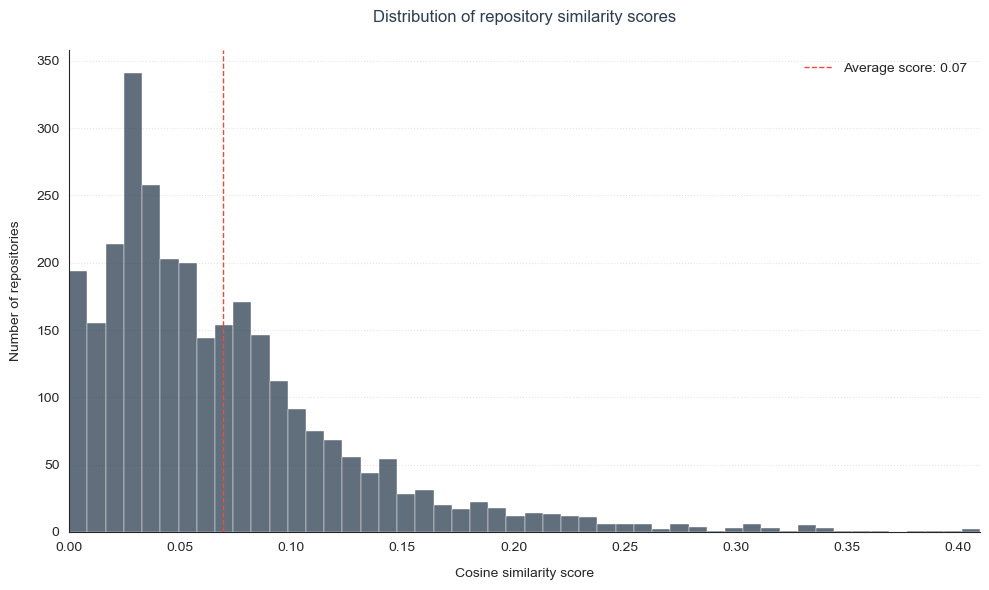

In [25]:
# get basic stats
print("--- Score statistics ---")
print(df_cosine_results['similarity_score'].describe())

# visualize distribution 
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df_cosine_results['similarity_score'], bins=50, color="#2c3e50", edgecolor="white", linewidth=0.3, ax=ax)
ax.margins(x=0)

# mean line
mean_val = df_cosine_results['similarity_score'].mean()
plt.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=1, label=f'Average score: {mean_val:.2f}')

sns.despine()

# font weights and titles
plt.title('Distribution of repository similarity scores', fontsize=12, pad=20, color='#2c3e50')
plt.xlabel('Cosine similarity score', fontsize=10, labelpad=10)
plt.ylabel('Number of repositories', fontsize=10, labelpad=10)

# legend and grid
plt.legend(frameon=False, fontsize=10)
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [26]:
# extract similarity scores
scores = np.array([r['similarity_score'] for r in cosine_results])

cuts = {
    "top 5%": 0.95,
    "top 10%": 0.90,
    "top 20%": 0.80,
}

rows = []
for label, p in cuts.items():
    thr = np.quantile(scores, p)
    n = (scores >= thr).sum()
    rows.append({
        "band": label,
        "percentile": p,
        "threshold_score": thr,
        "n_candidates": int(n)
    })

threshold_df = pd.DataFrame(rows)
print(threshold_df)

      band  percentile  threshold_score  n_candidates
0   top 5%        0.95         0.184223           147
1  top 10%        0.90         0.141428           294
2  top 20%        0.80         0.103604           588


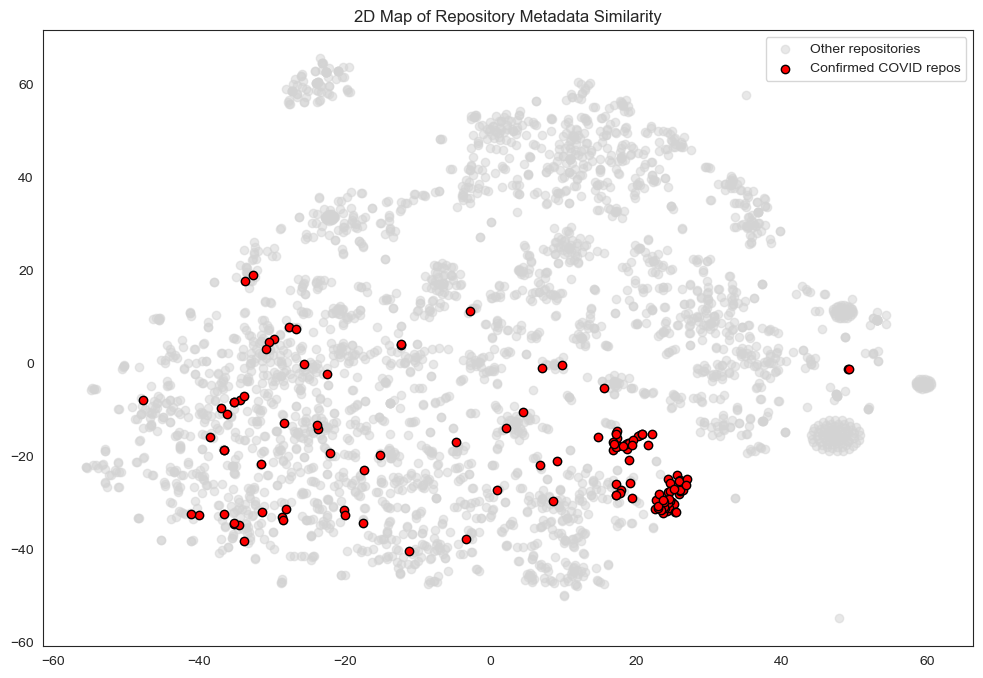

In [49]:
# reduce TF-IDF matrix to 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
vis_dims = tsne.fit_transform(tfidf_matrix.toarray())

# seperate coordinates
x = vis_dims[:, 0]
y = vis_dims[:, 1]

# plot
plt.figure(figsize=(12, 8))
plt.scatter(x, y, c='lightgrey', alpha=0.5, label='Other repositories') # all repos in light gray
plt.scatter(x[covid_indices], y[covid_indices], c='red', edgecolors='black', label='Confirmed COVID repos') # covid repos in red
plt.title('2D Map of Repository Metadata Similarity')
plt.legend()

plt.show()

In [33]:
# thresholds
scores = np.array([r['similarity_score'] for r in cosine_results])
thr_10 = np.quantile(scores, 0.90)
thr_5 = np.quantile(scores, 0.95)

# filter to top 10%
top_results = [r for r in cosine_results if r['similarity_score'] >= thr_10]

# extract data from top results with function
df_top_similarity = extract_fairsharing_records(top_results, add_similarity=True)

In [34]:
df_top_similarity.head(10)

,name,abbreviation,url,fs_id,fs_doi,description,status,record_type,countries,year_created,...,linked_licence_name,linked_licence_url,related_standard_name,standard_relation,cross_references,object_types,subjects,tags,publications,similarity_score
0,German Portal for Medical Research Data,FDPG,https://forschen-fuer-gesundheit.de/,7386,None,The FDPG is the German Portal for Medical Rese...,ready,repository,Germany,,...,None,None,None,None,https://www.re3data.org/repository/r3d100014444,dataset; physical object/material,Biomedical Science; Clinical Studies; Epidemio...,None,None,0.410045
1,Vivli,Vivli,https://vivli.org/,2719,10.25504/FAIRsharing.uovQrT,The Vivli data repository provides a global da...,ready,repository,Worldwide,,...,Vivli Data Use Agreement; Vivli Privacy Statement,https://vivli.org/resources/vivli-data-use-agr...,None,None,https://www.re3data.org/repository/r3d10001282...,dataset,Virology; Preclinical Studies; Biomedical Scie...,None,None,0.406009
2,HUNT Databank,None,https://hunt-db.medisin.ntnu.no/hunt-db/,7062,10.25504/FAIRsharing.37d135,HUNT Databank is a research database hosted by...,ready,repository,Norway,,...,None,None,None,None,https://www.re3data.org/repository/r3d10001129...,dataset,Clinical Studies; Epidemiology; Health Science,None,None,0.398216
3,International Traditional Medicine Clinical Tr...,ISRCTN Registry,http://www.isrctn.com/,2928,10.25504/FAIRsharing.01d14a,The ISRCTN registry is a primary clinical tria...,ready,repository,United Kingdom,,...,None,None,None,None,https://www.re3data.org/repository/r3d100013307,dataset,Virology; Preclinical Studies; Biomedical Scie...,None,None,0.387687
4,Australian New Zealand Clinical Trials Registry,ANZCTR,http://www.anzctr.org.au/,2927,10.25504/FAIRsharing.7f07dd,The Australian New Zealand Clinical Trials Reg...,ready,repository,Australia; New Zealand,,...,ANZCTR Terms and Conditions,http://www.anzctr.org.au/Support/Terms.aspx,None,None,https://www.re3data.org/repository/r3d100011164,dataset,Virology; Preclinical Studies; Biomedical Scie...,None,None,0.381429
5,UMIN Clinical Trials Registry,UMIN-CTR,https://www.umin.ac.jp/ctr/index.htm,2931,10.25504/FAIRsharing.802961,UMIN-CTR is a Clinical Trials Registry hosted ...,ready,repository,Japan,,...,None,None,None,None,https://www.re3data.org/repository/r3d100012003,dataset,Virology; Preclinical Studies; Clinical Studie...,None,None,0.363759
6,Models of Infectious Disease Agent Study Catalog,MIDAS Catalog,https://catalog.midasnetwork.us,5867,10.25504/FAIRsharing.4864a5,The MIDAS Catalog is a web-based platform host...,ready,knowledgebase,United States,,...,None,None,None,None,None,dataset; image; model; software application,Biomedical Science; Epidemiology; Public Healt...,None,None,0.357298
7,Clinical Trials Information System,CTIS,https://euclinicaltrials.eu/,4990,10.25504/FAIRsharing.dc6f5c,The Clinical Trials Information System (CTIS) ...,ready,repository,European Union,,...,None,None,None,None,None,dataset,Biomedical Science; Clinical Studies; Health S...,None,None,0.348813
8,Overview of Medical Research in the Netherlands,OMON,https://onderzoekmetmensen.nl/en,2932,10.25504/FAIRsharing.17b1e4,The Overview of Medical Research in the Nether...,ready,repository,Netherlands,,...,Creative Commons CC0 1.0 Universal (CC0 1.0) P...,https://creativecommons.org/publicdomain/zero/...,None,None,https://www.re3data.org/repository/r3d10001331...,dataset,Virology; Preclinical Studies; Clinical Studie...,None,None,0.337287
9,HealthData.gov,HealthData.gov,https://www.healthdata.gov/,2246,10.25504/FAIRsharing.kcpnmb,HealthData.gov makes high value health data mo...,ready,knowledgebase_and_repository,United States,,...,HHS Privacy Policy,http://www.hhs.gov/privacy.html,None,None,https://www.re3data.org/repository/r3d10001059...,document; dataset; image,Preclinical Studies; Biomedical Science; Healt...,None,None,0.337095


In [36]:
# double check that there's no overlap between the two dfs
overlap_ids = set(df_covid["fs_id"]) & set(df_top_similarity["fs_id"])
print(overlap_ids)

set()


In [37]:
df_top_similarity.to_csv("data/similar_databases.csv", index=False)

In [39]:
print(len(df_top_similarity))
print(df_top_similarity.info())

294
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   name                       294 non-null    object 
 1   abbreviation               225 non-null    object 
 2   url                        294 non-null    object 
 3   fs_id                      294 non-null    object 
 4   fs_doi                     277 non-null    object 
 5   description                294 non-null    object 
 6   status                     294 non-null    object 
 7   record_type                294 non-null    object 
 8   countries                  294 non-null    object 
 9   year_created               294 non-null    object 
 10  funder                     177 non-null    object 
 11  funder_type                177 non-null    object 
 12  maintaining_institution    264 non-null    object 
 13  maintaining_type           264 non-null    obj

**Looking for databases that are linked**

Checking relations:


1. "**shares data with**": "This database shares a portion of data with another database. This relation does not specify if the data being shared is from the resource you are editing, the resource being linked, or a combination of both."

2. "**extends**": "This is our most generic **database -> database** relationship. Useful when your resource extends a database, but other more precise relationships (shares_code_with, shares_data_with) are not suitable."

3. "**related-to**": "This is our most generic relationship, and can be used between most record types. Use this if the more fine-grained relationships are not applicable." **-> any database to any other database OR standard**

4. "**implements**": "This is our most generic **database -> standard** relationship. If your database uses a standard internally for some purpose, e.g. perhaps it utilises an RDF triplestore, but the other more precise relationships (accepts, outputs) are not suitable. Useful to e.g. standards developers, who want to know who is using their standard (even if only internally)."

5. "**accepts**": "Suitable for when a database accepts data that follows a particular standard. Such information is useful e.g. to researchers who need to know what standard to use so that they may deposit data with your database." **-> any database to any standard**

6. "**outputs**": "Suitable for when a database outputs data that follows a particular standard." **-> any database to any standard**

In [ ]:
from collections import defaultdict

# group links by relation using a dict
links_by_relation = defaultdict(list)

for item in covid_databases:
    rec = item['repo'] if isinstance(item, dict) and 'repo' in item else item
    attrs = rec.get("attributes", {})
    
    linking_records = attrs.get("linking_records", [])
    
    for link in linking_records:
        relation = link.get("relation")
        
        source_name = (
            attrs.get("metadata", {}).get("name")
            or attrs.get("abbreviation")
            or rec.get("name")
            or rec.get("id")
        )
        
        link_info = {
            "source_db_id": rec.get("id"),
            "source_db_name": source_name,
            "linked_db_id": link.get("linking_record_id"),
            "linked_db_name": link.get("linking_record_name"),
            "linked_db_registry": link.get("linking_record_registry"),
            "linked_db_type": link.get("linking_record_type"),
            "relation": relation,
        }
        
        links_by_relation[relation].append(link_info)


# print counts
for relation in ["shares_data_with", "extends", "related_to", "implements", "accepts", "outputs"]:
    print(f"Number of '{relation}' links found: {len(links_by_relation[relation])}")


# print links grouped by relation
for relation in ["shares_data_with", "extends", "related_to", "implements", "accepts", "outputs"]:
    links = links_by_relation[relation]
    if links:
        print(f"\n--- {relation} links ---")
        for link in links:
            print(link)

Number of 'shares_data_with' links found: 0
Number of 'extends' links found: 0
Number of 'related_to' links found: 0
Number of 'implements' links found: 0
Number of 'accepts' links found: 0
Number of 'outputs' links found: 0
